# Last 10 Bitcoin Price Predictions Comparison
This notebook compares the last 10 price predictions (separated by commas) from both the enhanced and base models.

## Install Required Libraries

In [1]:
!pip install transformers datasets torch peft accelerate matplotlib seaborn pandas numpy

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import json
import re



/tmp/xx/grpo_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!CUDA_VISIBLE_DEVICES=3

## Load Required Libraries and Models

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

base_model_id = './Qwen3-4B-Instruct-2507'
adapter_path = './qwen_bitcoin_enhanced_grpo_no_unsloth_bigger_unsloth_10000/checkpoint-500'
output_merged_model_path = './Qwen3-4B-merged-bitcoin-chat'


base_qwen_tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    trust_remote_code=True
)
if base_qwen_tokenizer.pad_token is None:
    base_qwen_tokenizer.pad_token = base_qwen_tokenizer.eos_token


base_qwen_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(
    adapter_path,
    trust_remote_code=True
)

base_qwen_model.resize_token_embeddings(len(tokenizer))

print("Loading LoRA adapter from:", adapter_path)
enhanced_model = PeftModel.from_pretrained(base_qwen_model, adapter_path)
enhanced_model.eval()
print("\n✅ Adapter loaded successfully!")



`torch_dtype` is deprecated! Use `dtype` instead!



Loading checkpoint shards:   0%|                                                                                                                     | 0/3 [00:00<?, ?it/s]


Loading checkpoint shards:  33%|████████████████████████████████████▎                                                                        | 1/3 [00:01<00:02,  1.30s/it]


Loading checkpoint shards:  67%|████████████████████████████████████████████████████████████████████████▋                                    | 2/3 [00:02<00:01,  1.29s/it]


Loading checkpoint shards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.14it/s]

Loading LoRA adapter from: ./qwen_bitcoin_enhanced_grpo_no_unsloth_bigger_unsloth_10000/checkpoint-500



✅ Adapter loaded successfully!


/tmp/xx/grpo_env/lib/python3.10/site-packages/peft/peft_model.py:585: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_B.defa

## Load Test Dataset

In [5]:
test_dataset = load_dataset('tahamajs/bitcoin-enhanced-prediction-dataset-with-local-comprehensive-news', split='train')
print(f"Loaded {len(test_dataset)} test samples")
shuffled_dataset = test_dataset.shuffle(seed=42)


Loaded 2303 test samples


## Utility Functions for Price Extraction

In [6]:
from typing import Dict, Any, Union


def extract_trading_recommendation_from_text(text):
    """Extract structured trading recommendation with 10-day forecast from model output"""
    import json
    
    text = text.strip()
    
    json_patterns = [
        r'\{[^{}]*"forecast_10d"[^{}]*\}',
        r'\{(?:[^{}]|{[^{}]*})*"forecast_10d"(?:[^{}]|{[^{}]*})*\}',
    ]
    
    for pattern in json_patterns:
        matches = re.findall(pattern, text, re.DOTALL)
        for match in matches:
            try:
                cleaned_json = match.strip()
                cleaned_json = re.sub(r',\s*}', '}', cleaned_json) 
                cleaned_json = re.sub(r',\s*]', ']', cleaned_json) 
                
                parsed = json.loads(cleaned_json)
                
                if all(key in parsed for key in ['action', 'confidence', 'forecast_10d']):
                    if isinstance(parsed['forecast_10d'], list) and len(parsed['forecast_10d']) > 0:
                        try:
                            parsed['forecast_10d'] = [float(x) for x in parsed['forecast_10d']]
                            return parsed
                        except (ValueError, TypeError):
                            continue
            except json.JSONDecodeError:
                continue
    
    code_block_pattern = r'```(?:json)?\s*(\{.*?\})\s*```'
    code_matches = re.findall(code_block_pattern, text, re.DOTALL)
    for match in code_matches:
        try:
            parsed = json.loads(match.strip())
            if 'forecast_10d' in parsed:
                return parsed
        except json.JSONDecodeError:
            continue
    
    bracket_pattern = r'\{[^{}]*\}'
    bracket_matches = re.findall(bracket_pattern, text, re.DOTALL)
    for match in bracket_matches:
        try:
            parsed = json.loads(match.strip())
            if isinstance(parsed, dict) and 'forecast_10d' in parsed:
                return parsed
        except json.JSONDecodeError:
            continue
    
    forecast_patterns = [
        r'"forecast_10d"\s*:\s*\[([^\]]+)\]',
        r'forecast_10d["\']?\s*:\s*\[([^\]]+)\]',
        r'\[(\d+(?:\.\d+)?(?:\s*,\s*\d+(?:\.\d+)?){9,})\]'
    ]
    
    for pattern in forecast_patterns:
        forecast_match = re.search(pattern, text, re.IGNORECASE)
        if forecast_match:
            try:
                price_str = forecast_match.group(1)
                price_str = re.sub(r'\s+', ' ', price_str)
                prices = []
                
                if ',' in price_str:
                    prices = [float(p.strip()) for p in price_str.split(',') if p.strip()]
                elif ' ' in price_str:
                    prices = [float(p.strip()) for p in price_str.split(' ') if p.strip()]
                else:
                    prices = [float(price_str.strip())]
                
                if len(prices) >= 5:  
                    return {
                        'action': 'UNKNOWN',
                        'confidence': 0,
                        'forecast_10d': prices[:10], 
                        'stop_loss': None,
                        'take_profit': None
                    }
            except (ValueError, TypeError):
                continue
    
    number_patterns = [
        r'(\d+(?:\.\d+)?(?:\s*,\s*\d+(?:\.\d+)?)+)',  
        r'(\d+(?:\.\d+)?(?:\s+\d+(?:\.\d+)?)+)',   
    ]
    
    for pattern in number_patterns:
        matches = re.findall(pattern, text)
        if matches:
            try:
                longest_match = max(matches, key=len)
                if ',' in longest_match:
                    prices = [float(p.strip()) for p in longest_match.split(',') if p.strip()]
                else:
                    prices = [float(p.strip()) for p in longest_match.split() if p.strip()]
                
                if len(prices) >= 3: 
                    return {
                        'action': 'UNKNOWN',
                        'confidence': 0,
                        'forecast_10d': prices[:10],
                        'stop_loss': None,
                        'take_profit': None
                    }
            except (ValueError, TypeError):
                continue
    
    single_number_pattern = r'(\d+(?:\.\d+)?)'
    single_matches = re.findall(single_number_pattern, text)
    if single_matches:
        try:
            for match in single_matches:
                price = float(match)
                if 1000 <= price <= 200000:
                    return {
                        'action': 'UNKNOWN',
                        'confidence': 0,
                        'forecast_10d': [price],
                        'stop_loss': None,
                        'take_profit': None
                    }
        except ValueError:
            pass
    
    return None

def extract_last_10_prices_from_text(text):
    """Extract the last 10 price predictions from model output (backward compatibility)"""
    recommendation = extract_trading_recommendation_from_text(text)
    if recommendation and 'forecast_10d' in recommendation:
        return recommendation['forecast_10d']
    return []

def extract_all_prices_from_text(text):
    """Extract all price predictions from model output (backward compatibility)"""
    return extract_last_10_prices_from_text(text)

def format_input_enhanced(example):
    """Format input for the enhanced model"""
    instruction = example.get('instruction', '')
    user_input = example.get('input', '')
    
    enhanced_instruction = """You are a Bitcoin investment advisor. Based on the provided market data and news, provide a trading recommendation in JSON format.

IMPORTANT: Your response must be a valid JSON object with exactly this structure:
{
  "action": "BUY" or "SELL" or "HOLD",
  "confidence": number between 0-100,
  "stop_loss": number (price),
  "take_profit": number (price),
  "forecast_10d": [price1, price2, price3, price4, price5, price6, price7, price8, price9, price10]
}

Example:
{"action":"SELL","confidence":68,"stop_loss":9593.73,"take_profit":8370.01,"forecast_10d":[9174.91, 8277.01, 6955.27, 7754.00, 7621.30, 8265.59, 8736.98, 8621.90, 8129.97, 8926.57]}

Return ONLY the JSON object, no other text."""
    
    messages = [
        {'role': 'system', 'content': enhanced_instruction},
        {'role': 'user', 'content': f"{instruction}\n\n{user_input}\n\nProvide your trading recommendation as a JSON object only:"}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_input_base(example):
    """Format input for base Qwen model"""
    instruction = example.get('instruction', '')
    user_input = example.get('input', '')
    
    bitcoin_instruction = """You are a Bitcoin investment advisor. Based on the provided market data and news, provide a trading recommendation in JSON format.

IMPORTANT: Your response must be a valid JSON object with exactly this structure:
{
  "action": "BUY" or "SELL" or "HOLD",
  "confidence": number between 0-100,
  "stop_loss": number (price),
  "take_profit": number (price),
  "forecast_10d": [price1, price2, price3, price4, price5, price6, price7, price8, price9, price10]
}

Example:
{"action":"SELL","confidence":68,"stop_loss":9593.73,"take_profit":8370.01,"forecast_10d":[9174.91, 8277.01, 6955.27, 7754.00, 7621.30, 8265.59, 8736.98, 8621.90, 8129.97, 8926.57]}

Return ONLY the JSON object, no other text."""
    
    messages = [
        {'role': 'system', 'content': bitcoin_instruction},
        {'role': 'user', 'content': f"{instruction}\n\n{user_input}\n\nProvide your trading recommendation as a JSON object only:"}
    ]
    return base_qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

print("Utility functions loaded!")

def post_process_recommendation(recommendation, current_price=None):
    """Post-process and validate trading recommendation"""
    if not recommendation:
        return None
    
    processed = {
        'action': recommendation.get('action', 'UNKNOWN').upper(),
        'confidence': max(0, min(100, int(recommendation.get('confidence', 0)))),
        'forecast_10d': recommendation.get('forecast_10d', []),
        'stop_loss': recommendation.get('stop_loss'),
        'take_profit': recommendation.get('take_profit')
    }
    
    if processed['forecast_10d']:
        valid_prices = []
        for price in processed['forecast_10d']:
            try:
                price_float = float(price)
                if 100 <= price_float <= 1000000:
                    valid_prices.append(price_float)
            except (ValueError, TypeError):
                continue
        
        processed['forecast_10d'] = valid_prices[:10]
    
    valid_actions = ['BUY', 'SELL', 'HOLD', 'UNKNOWN']
    if processed['action'] not in valid_actions:
        processed['action'] = 'UNKNOWN'
    
    processed['is_valid'] = len(processed['forecast_10d']) > 0
    processed['forecast_length'] = len(processed['forecast_10d'])
    
    return processed

def format_input(example: Union[Dict[str, str], str], tokenizer: Any) -> str:
    """
    Generic function to format input for a chat model.
    Handles both dictionary and plain string inputs for the 'example'.
    """
    messages = []
    
    if isinstance(example, dict):
        messages = [
            {'role': 'system', 'content': example.get('instruction', 'You are a helpful assistant.')},
            {'role': 'user', 'content': example.get('input', '')}
        ]
    elif isinstance(example, str):
        messages = [
            {'role': 'system', 'content': 'You are a helpful assistant.'},
            {'role': 'user', 'content': example} 
        ]
    else:
        raise TypeError(f"Unsupported type for 'example': {type(example)}")

    return tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True,
        enable_thinking=False
    )


Utility functions loaded!


## Generate Last 10 Price Predictions

Generating price predictions for 200 samples...




Processing Samples:   0%|                                                                                                                          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Processing Samples:   0%|▌                                                                                                               | 1/200 [00:18<1:02:02, 18.71s/it]


Processing Samples:   1%|█▏                                                                                                                | 2/200 [00:36<59:48, 18.12s/it]

...


Processing Samples:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▉ | 198/200 [56:34<00:34, 17.45s/it]


Processing Samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [56:51<00:17, 17.50s/it]


Processing Samples: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [57:07<00:00, 16.98s/it]


Processing Samples: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [57:07<00:00, 17.14s/it]


✅ Generated predictions for 200 samples!

Preparing data for metric calculation...

📊 Calculating metrics based on 200 valid forecast samples and 200 valid action samples.

========================= REGRESSION METRICS =========================
Lower is better for MSE, RMSE, and MAE. Higher is better for R-Squared.

                Enhanced Model
MSE               958,332.4250
RMSE                  978.9445
MAE                   730.9296
R-Squared (R²)          0.4869

======================== CLASSIFICATION METRICS ========================
Accuracy, Precision, Recall, and F1-Score are reported. Higher is better (range 0-1).

--- Enhanced Model ---
Overall Accuracy: 0.3750

              precision    recall  f1-score   support

         BUY       0.51      0.36      0.42        83
        HOLD       0.06      0.25      0.10        16
        SELL       0.54      0.41      0.46       101

    accuracy                           0.38       200
   macro avg       0.37      0.34      0.33  

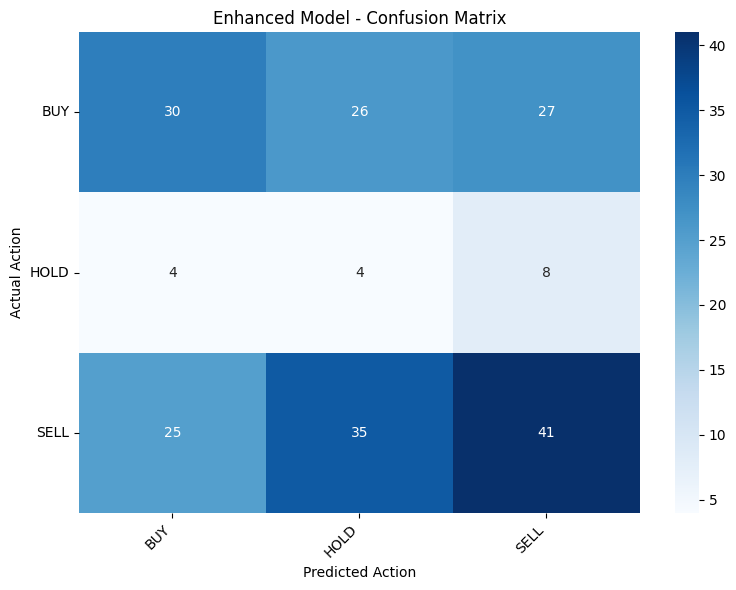


✅ Metric calculation and visualization complete.


In [ ]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)


def generate_prediction(model, tokenizer, text_input):
    """
    Encapsulates the model generation logic to avoid code duplication.
    """
    inputs = tokenizer(
        text_input, return_tensors="pt", truncation=True, max_length=10000
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2048,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_text = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True
    )
    return generated_text


def _get_forecast_prices(recommendation: dict) -> list:
    """
    Safely extracts the 'forecast_10d' list from a recommendation dictionary.
    """
    if not recommendation or "forecast_10d" not in recommendation:
        return []
    prices = recommendation["forecast_10d"]
    return prices if isinstance(prices, list) else []


def plot_confusion_matrix(cm, class_names, title):
    """
    Renders a confusion matrix using Seaborn's heatmap.
    """
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    plt.figure(figsize=(8, 6))
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
    except ValueError:
        print(f"Error creating heatmap for {title}. Skipping.")
        return
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha="right")
    heatmap.xaxis.set_ticklabels(
        heatmap.xaxis.get_ticklabels(), rotation=45, ha="right"
    )
    plt.ylabel("Actual Action")
    plt.xlabel("Predicted Action")
    plt.title(title)
    plt.tight_layout()
    plt.show()


num_samples = 200
results = []
print(f"Generating price predictions for {num_samples} samples...\n")

for i in tqdm(range(min(num_samples, len(test_dataset))), desc="Processing Samples"):
    test_example = test_dataset[i]

    enhanced_prompt = format_input(test_example, tokenizer)
    enhanced_generated = generate_prediction(enhanced_model, tokenizer, enhanced_prompt)

    enhanced_recommendation = extract_trading_recommendation_from_text(
        enhanced_generated
    )
    actual_recommendation = extract_trading_recommendation_from_text(
        test_example.get("output", "")
    )

    enhanced_prices_full = _get_forecast_prices(enhanced_recommendation)
    actual_prices_full = _get_forecast_prices(actual_recommendation)

    sample_result = {
        "sample_id": i,
        "enhanced_recommendation": enhanced_recommendation,
        "actual_recommendation": actual_recommendation,
        "enhanced_last_10": enhanced_prices_full[-10:],
        "actual_last_10": actual_prices_full[-10:],
    }
    results.append(sample_result)

print(f"\n✅ Generated predictions for {len(results)} samples!")


all_actual_prices, all_enhanced_prices = [], []
all_actual_actions, all_enhanced_actions = [], []

print("\nPreparing data for metric calculation...")
for res in results:
    actual_prices = res["actual_last_10"]
    enhanced_prices = res["enhanced_last_10"]

    if len(actual_prices) == 10 and len(enhanced_prices) == 10:
        all_actual_prices.extend(actual_prices)
        all_enhanced_prices.extend(enhanced_prices)

        actual_action = res.get("actual_recommendation", {}).get("action")
        enhanced_action = res.get("enhanced_recommendation", {}).get("action")

        if actual_action and enhanced_action:
            all_actual_actions.append(actual_action)
            all_enhanced_actions.append(enhanced_action)
        else:
            print(
                f"  - WARNING: Skipping action for Sample {res['sample_id']} due to missing action value."
            )
    else:
        print(
            f"  - WARNING: Skipping forecast for Sample {res['sample_id']} due to mismatched forecast lengths."
        )


if not all_actual_prices or not all_actual_actions:
    print("\n❌ Not enough valid data to calculate comprehensive metrics. Exiting.")
else:
    print(
        f"\n📊 Calculating metrics based on {len(all_actual_prices) // 10} valid forecast samples and {len(all_actual_actions)} valid action samples."
    )

    actual_np = np.array(all_actual_prices)
    enhanced_np = np.array(all_enhanced_prices)

    print("\n" + "=" * 25 + " REGRESSION METRICS " + "=" * 25)
    print("Lower is better for MSE, RMSE, and MAE. Higher is better for R-Squared.\n")

    metrics_data = {
        "Enhanced Model": {
            "MSE": mean_squared_error(actual_np, enhanced_np),
            "RMSE": np.sqrt(mean_squared_error(actual_np, enhanced_np)),
            "MAE": mean_absolute_error(actual_np, enhanced_np),
            "R-Squared (R²)": r2_score(actual_np, enhanced_np),
        }
    }

    metrics_df = pd.DataFrame(metrics_data)
    print(metrics_df.to_string(float_format="{:,.4f}".format))
    print("=" * 72)

    print("\n" + "=" * 24 + " CLASSIFICATION METRICS " + "=" * 24)
    print(
        "Accuracy, Precision, Recall, and F1-Score are reported. Higher is better (range 0-1).\n"
    )

    action_labels = sorted(list(set(all_actual_actions)))

    print("--- Enhanced Model ---")
    print(
        f"Overall Accuracy: {accuracy_score(all_actual_actions, all_enhanced_actions):.4f}\n"
    )
    print(
        classification_report(
            all_actual_actions,
            all_enhanced_actions,
            labels=action_labels,
            zero_division=0,
        )
    )
    print("=" * 72)

    print("\nGenerating Confusion Matrix...")

    cm_enhanced = confusion_matrix(
        all_actual_actions, all_enhanced_actions, labels=action_labels
    )
    plot_confusion_matrix(
        cm_enhanced,
        class_names=action_labels,
        title="Enhanced Model - Confusion Matrix",
    )

    print("\n✅ Metric calculation and visualization complete.")

## Visualization of Last 10 Prices

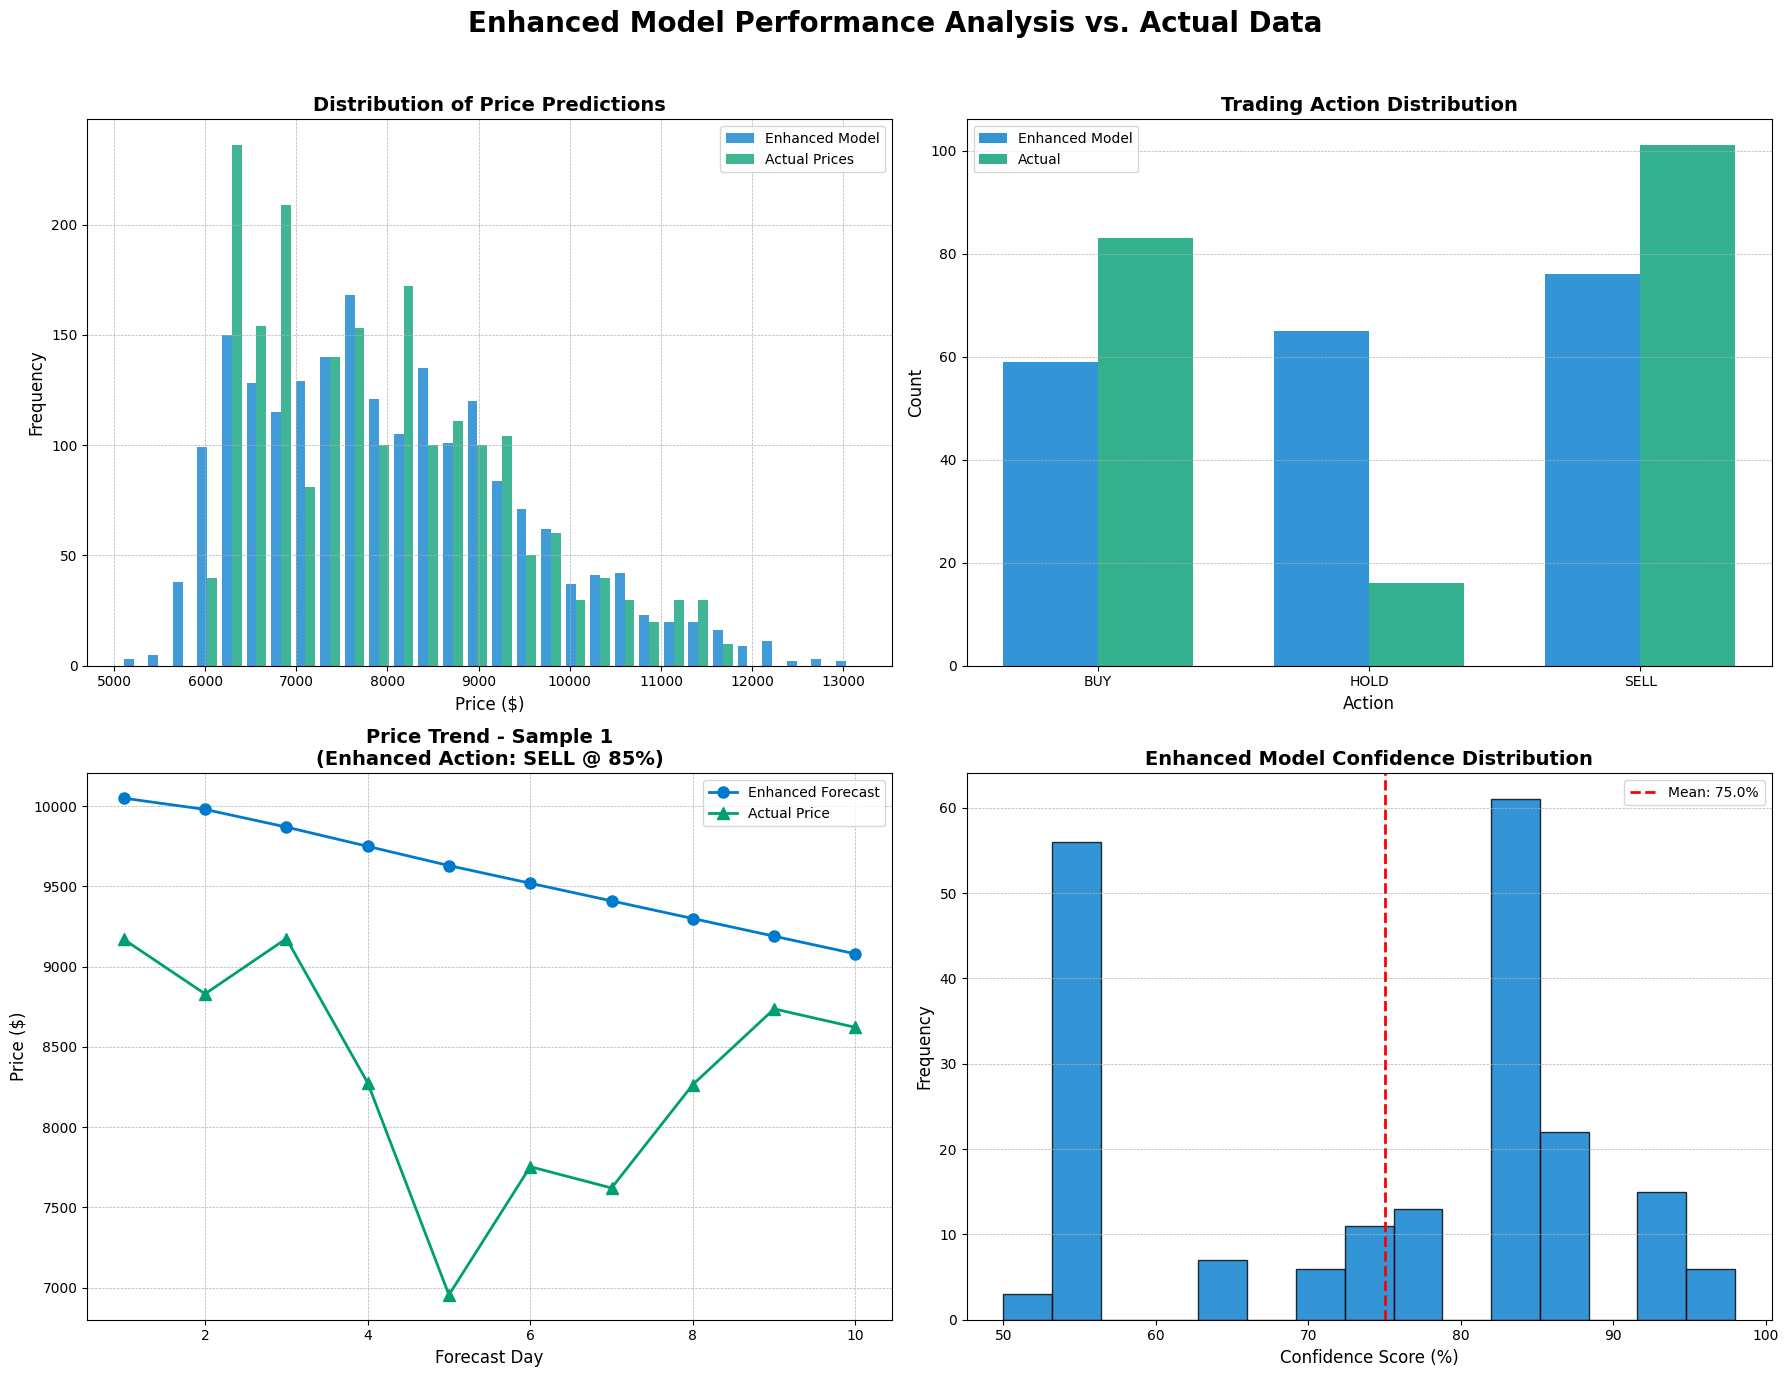

📊 Enhanced model performance visualization saved as 'enhanced_model_performance_visualization.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


valid_comparisons = [
    r for r in results if
    'action' in r.get('enhanced_recommendation', {}) and
    'action' in r.get('actual_recommendation', {}) and
    len(r.get('enhanced_last_10', [])) == 10 and
    len(r.get('actual_last_10', [])) == 10
]

if valid_comparisons:
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Enhanced Model Performance Analysis vs. Actual Data', fontsize=20, fontweight='bold')

    
    enhanced_last_10_all = [price for res in valid_comparisons for price in res['enhanced_last_10']]
    actual_last_10_all = [price for res in valid_comparisons for price in res['actual_last_10']]
    
    axes[0, 0].hist([enhanced_last_10_all, actual_last_10_all],
                    bins=30, alpha=0.75,
                    label=['Enhanced Model', 'Actual Prices'],
                    color=['
    axes[0, 0].set_title('Distribution of Price Predictions', fontweight='bold', fontsize=14)
    axes[0, 0].set_xlabel('Price ($)', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, which='both', linestyle='--', linewidth=0.5)

    
    enhanced_actions = [res['enhanced_recommendation']['action'] for res in valid_comparisons]
    actual_actions = [res['actual_recommendation']['action'] for res in valid_comparisons]

    all_actions = sorted(list(set(enhanced_actions + actual_actions)))
    enhanced_counts = [enhanced_actions.count(action) for action in all_actions]
    actual_counts = [actual_actions.count(action) for action in all_actions]

    x = np.arange(len(all_actions))
    width = 0.35

    axes[0, 1].bar(x - width/2, enhanced_counts, width, label='Enhanced Model', alpha=0.8, color='
    axes[0, 1].bar(x + width/2, actual_counts, width, label='Actual', alpha=0.8, color='

    axes[0, 1].set_title('Trading Action Distribution', fontweight='bold', fontsize=14)
    axes[0, 1].set_xlabel('Action', fontsize=12)
    axes[0, 1].set_ylabel('Count', fontsize=12)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(all_actions)
    axes[0, 1].legend()
    axes[0, 1].grid(True, axis='y', linestyle='--', linewidth=0.5)

    
    
    sample_to_plot = valid_comparisons[0]
    days = list(range(1, 11))

    axes[1, 0].plot(days, sample_to_plot['enhanced_last_10'], 'o-', label='Enhanced Forecast', color='
    axes[1, 0].plot(days, sample_to_plot['actual_last_10'], '^-', label='Actual Price', color='

    enhanced_rec = sample_to_plot['enhanced_recommendation']
    title_text = (f'Price Trend - Sample {sample_to_plot["sample_id"]+1}\n'
                  f'(Enhanced Action: {enhanced_rec.get("action")} @ {enhanced_rec.get("confidence", "N/A")}%)')

    axes[1, 0].set_title(title_text, fontweight='bold', fontsize=14)
    axes[1, 0].set_xlabel('Forecast Day', fontsize=12)
    axes[1, 0].set_ylabel('Price ($)', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)

    
    enhanced_confidences = [res['enhanced_recommendation'].get('confidence') 
                           for res in valid_comparisons if res['enhanced_recommendation'].get('confidence') is not None]

    if enhanced_confidences:
        axes[1, 1].hist(enhanced_confidences, bins=15, alpha=0.8, color='
        axes[1, 1].set_title('Enhanced Model Confidence Distribution', fontweight='bold', fontsize=14)
        axes[1, 1].set_xlabel('Confidence Score (%)', fontsize=12)
        axes[1, 1].set_ylabel('Frequency', fontsize=12)
        axes[1, 1].axvline(np.mean(enhanced_confidences), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(enhanced_confidences):.1f}%')
        axes[1, 1].legend()
        axes[1, 1].grid(True, axis='y', linestyle='--', linewidth=0.5)
    else:
        axes[1, 1].text(0.5, 0.5, 'No Confidence Data Available', ha='center', va='center', fontsize=12)
        axes[1, 1].set_title('Enhanced Model Confidence Distribution', fontweight='bold', fontsize=14)


    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    
    
    save_path = 'enhanced_model_performance_visualization.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"📊 Enhanced model performance visualization saved as '{save_path}'")

else:
    print("❌ Cannot create visualizations - no valid comparison data found.")

## Detailed Last 10 Prices Analysis

In [ ]:
import numpy as np
import json


valid_comparisons = results
enhanced_actions = [r["enhanced_recommendation"]["action"] for r in valid_comparisons]
actual_actions = [r["actual_recommendation"]["action"] for r in valid_comparisons]
action_accuracy = np.mean(
    [1 if e == a else 0 for e, a in zip(enhanced_actions, actual_actions)]
)


if valid_comparisons:

    enhanced_mae_last_10 = []

    for comp in valid_comparisons:

        if (
            len(comp.get("enhanced_last_10", [])) == 10
            and len(comp.get("actual_last_10", [])) == 10
        ):
            enhanced_prices = np.array(comp["enhanced_last_10"])
            actual_prices = np.array(comp["actual_last_10"])

            mae = np.mean(np.abs(enhanced_prices - actual_prices))
            enhanced_mae_last_10.append(mae)

    print("=" * 80)
    print("🎯 ENHANCED MODEL ACCURACY ANALYSIS")
    print("=" * 80)

    if enhanced_mae_last_10:
        mean_mae = np.mean(enhanced_mae_last_10)
        std_mae = np.std(enhanced_mae_last_10)

        print(f"\n📊 Mean Absolute Error (MAE) for Last 10 Prices:")

        print(f"  - Enhanced Model MAE: ${mean_mae:,.2f} (±${std_mae:,.2f})")
    else:
        mean_mae = None

    detailed_results = {
        "summary": {
            "total_samples_analyzed": len(valid_comparisons),
            "model_mae_last_10": float(mean_mae) if mean_mae is not None else None,
            "trading_recommendations_summary": {
                "action_accuracy": (
                    float(action_accuracy) if "action_accuracy" in locals() else None
                ),
                "enhanced_actions_distribution": {
                    action: enhanced_actions.count(action)
                    for action in set(enhanced_actions)
                },
                "actual_actions_distribution": {
                    action: actual_actions.count(action)
                    for action in set(actual_actions)
                },
            },
        },
        "detailed_comparisons": [],
    }

    for comp in valid_comparisons:
        comparison_data = {
            "sample_id": comp["sample_id"],
            "forecast_mae": (
                float(
                    np.mean(
                        np.abs(
                            np.array(comp["enhanced_last_10"])
                            - np.array(comp["actual_last_10"])
                        )
                    )
                )
                if comp["enhanced_last_10"] and comp["actual_last_10"]
                else None
            ),
            "enhanced_last_10_forecast": [
                float(p) for p in comp.get("enhanced_last_10", [])
            ],
            "actual_last_10_prices": [float(p) for p in comp.get("actual_last_10", [])],
            "enhanced_recommendation": comp.get("enhanced_recommendation"),
            "actual_recommendation": comp.get("actual_recommendation"),
            "enhanced_generated_text": comp.get("enhanced_text", ""),
        }
        detailed_results["detailed_comparisons"].append(comparison_data)

    save_path = "enhanced_model_analysis_grpo.json"
    with open(save_path, "w") as f:
        json.dump(detailed_results, f, indent=4)

    print(f"\n💾 Detailed analysis saved to '{save_path}'")

else:
    print("❌ No valid data for detailed analysis")

🎯 ENHANCED MODEL ACCURACY ANALYSIS

📊 Mean Absolute Error (MAE) for Last 10 Prices:
  - Enhanced Model MAE: $730.93 (±$495.57)

💾 Detailed analysis saved to 'enhanced_model_analysis_grpo.json'


## Show Raw Model Outputs for Last Few Samples

In [ ]:
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.text import Text
import numpy as np


def display_results_summary(results: list):
    """
    Displays a rich, formatted summary of the last few enhanced model predictions.
    """
    if not results:
        print("❌ No results to display")
        return

    console = Console()
    console.print("\n" + "=" * 100)
    console.print(
        "[bold cyan]🔍 ENHANCED MODEL OUTPUT ANALYSIS (Last 3 Samples)[/bold cyan]"
    )
    console.print("=" * 100 + "\n")

    action_colors = {
        "BUY": "bold green",
        "SELL": "bold red",
        "HOLD": "bold yellow",
        "N/A": "dim white",
    }

    for result in results[-3:]:

        table = Table(show_header=True, header_style="bold magenta", box=None)
        table.add_column("Metric", style="dim", width=15)
        table.add_column("Enhanced Model 🔥")
        table.add_column("Actual Data 🎯")

        enh_rec = result.get("enhanced_recommendation") or {}
        act_rec = result.get("actual_recommendation") or {}

        enh_action = enh_rec.get("action", "N/A")
        act_action = act_rec.get("action", "N/A")

        enh_prices = result.get("enhanced_last_10", [])
        act_prices = result.get("actual_last_10", [])

        table.add_row(
            "Action",
            Text(enh_action, style=action_colors.get(enh_action)),
            Text(act_action, style=action_colors.get(act_action)),
        )
        table.add_row(
            "Confidence",
            f"{enh_rec.get('confidence', 'N/A')} %",
            f"{act_rec.get('confidence', 'N/A')} %",
        )
        table.add_row(
            "Forecast Count",
            f"✅ {len(enh_prices)}" if enh_prices else f"❌ 0",
            f"✅ {len(act_prices)}" if act_prices else f"❌ 0",
        )
        table.add_row("Forecast Prices", str(enh_prices), str(act_prices))
        table.add_row(
            "Raw Output", f"\"{result.get('enhanced_text', '')[:150]}...\"", "-"
        )

        panel_title = f"📋 SAMPLE {result['sample_id']+1}"
        console.print(Panel(table, title=panel_title, border_style="cyan"))
        console.print()


display_results_summary(results)

====================================================================================================

🔍 ENHANCED MODEL OUTPUT ANALYSIS (Last 3 Samples)

====================================================================================================

╭───────────────────────────────────────────────── 📋 SAMPLE 198 ─────────────────────────────────────────────────╮
│  Metric           Enhanced Model 🔥                              Actual Data 🎯                                 │
│  Action           BUY                                            BUY                                            │
│  Confidence       75 %                                           99 %                                           │
│  Forecast Count   ✅ 10                                          ✅ 10                                          │
│  Forecast Prices  [6350.0, 6400.0, 6450.0, 6500.0, 6550.0,       [6580.63, 6423.76, 6506.07, 6308.53, 6488.76,  │
│                   6600.0, 6650.0, 6700.0, 6750.0, 6800.0]        6376.71, 6534.88, 6719.96, 6763.19, 6707.26]   │
│  Raw Output       "..."                                          -                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 📋 SAMPLE 199 ─────────────────────────────────────────────────╮
│  Metric           Enhanced Model 🔥                              Actual Data 🎯                                 │
│  Action           HOLD                                           BUY                                            │
│  Confidence       65 %                                           99 %                                           │
│  Forecast Count   ✅ 10                                          ✅ 10                                          │
│  Forecast Prices  [6334.73, 6345.21, 6360.1, 6375.32, 6389.45,   [6423.76, 6506.07, 6308.53, 6488.76, 6376.71,  │
│                   6402.1, 6415.23, 6428.0, 6440.5, 6453.0]       6534.88, 6719.96, 6763.19, 6707.26, 6884.64]   │
│  Raw Output       "..."                                          -                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 📋 SAMPLE 200 ─────────────────────────────────────────────────╮
│  Metric           Enhanced Model 🔥                              Actual Data 🎯                                 │
│  Action           BUY                                            BUY                                            │
│  Confidence       75 %                                           99 %                                           │
│  Forecast Count   ✅ 10                                          ✅ 10                                          │
│  Forecast Prices  [6620.0, 6680.0, 6740.0, 6800.0, 6860.0,       [6506.07, 6308.53, 6488.76, 6376.71, 6534.88,  │
│                   6920.0, 7000.0, 7080.0, 7160.0, 7240.0]        6719.96, 6763.19, 6707.26, 6884.64, 7096.28]   │
│  Raw Output       "..."                                          -                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
import json
import numpy as np
from typing import List, Dict, Any


def save_results_to_json(
    results: List[Dict[str, Any]],
    filename: str = "all_model_results_fine_tuned_grpo.json",
):
    """
    Saves a list of result dictionaries to a formatted JSON file.

    Args:
        results (List[Dict[str, Any]]): The list of result dictionaries.
        filename (str): The name of the output JSON file.
    """
    if not results:
        print("❌ No results to save.")
        return

    print(f"Attempting to save {len(results)} results to '{filename}'...")

    try:
        with open(filename, "w", encoding="utf-8") as f:

            json.dump(results, f, indent=4, ensure_ascii=False)

        print(f"✅ Results successfully saved to '{filename}'")
    except TypeError as e:
        print(f"❌ Error: Data contains a type that cannot be converted to JSON. {e}")
    except Exception as e:
        print(f"❌ An error occurred while saving the file: {e}")


save_results_to_json(results)

Attempting to save 200 results to 'all_model_results_fine_tuned_grpo.json'...
✅ Results successfully saved to 'all_model_results_fine_tuned_grpo.json'
